## Goal
The goal of this sprint is to examine the examples that the model predicted incorrectly, rather than looking at Accuracy or Recall.

## Research Notes

1) Why is Error Analysis an essential step after model evaluation?
2) Why shouldn't we rely only on evaluation metrics such as Accuracy or Recall?
3) Suppose two models have identical Accuracy. Can one still make more harmful mistakes than the other? Explain.
4) What kinds of patterns might appear among misclassified samples? Examples?
5) If you discover that most prediction errors come from one specific customer group, what actions could you take?
6) Imagine your model is deployed in production. After several months, you notice prediction performance has started to decrease. How could systematic error analysis help determine whether the problem comes from:

- poor model generalization,
- data quality,
- concept drift,
- or feature engineering?

---

- 1-Error analysis helps identify where and why the model fails, allowing us to improve preprocessing, feature engineering, model selection, or threshold tuning.

- 2-Different metrics measure different aspects of model performance, and the most important metric depends on the business objective.

- 3-Yes. Two models may have identical Accuracy while making different types of errors. One model may produce many False Negatives, while another may produce more False Positives. Depending on the business problem, these mistakes can have very different costs.

- 4-Misclassified samples may belong to specific groups, such as new customers, high-paying customers, or noisy and borderline cases.

- 5-Improve data quality, collect more samples, engineer better features, tune the model, or balance the dataset for that customer group.

- 6-Systematic error analysis helps identify whether performance degradation is caused by poor generalization, data quality issues, concept drift, or inadequate feature engineering, enabling appropriate corrective actions.

In [1]:
# Imports 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import shap
import joblib

In [2]:
# Load Clean Dataset
df = pd.read_csv('../data/processed/customer_churn_clean.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Feature & Target Separation
X = df.drop(columns='Churn')
y = df['Churn'].map({"No": 0, "Yes": 1})

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=42, stratify=y)

In [5]:
# Load Model
model = joblib.load("../models/logistic_regression_pipeline.joblib")

In [6]:
# Prediction Table
pred = model.predict(X_test)

proba = model.predict_proba(X_test)[:, 1]

In [44]:
data = {
    'Actual': y_test,
    'Predicted': pred,
    'IsCorrect': y_test == pred,
    'Probability': proba
}
prediction_table = pd.DataFrame(data)

In [45]:
prediction_table

,Actual,Predicted,IsCorrect,Probability
4214,0,0,True,0.186459
1815,0,0,True,0.338233
2370,0,0,True,0.050331
5453,0,0,True,0.036847
1786,0,0,True,0.039021
...,...,...,...,...
4677,0,0,True,0.139279
4760,0,0,True,0.001400
6141,0,0,True,0.495236
3229,0,0,True,0.015337


In [48]:
# Adding a PredictionType Column to DF
conditions = [
    (prediction_table["Actual"] == 1) & (prediction_table["Predicted"] == 1),
    (prediction_table["Actual"] == 0) & (prediction_table["Predicted"] == 0),
    (prediction_table["Actual"] == 0) & (prediction_table["Predicted"] == 1),
    (prediction_table["Actual"] == 1) & (prediction_table["Predicted"] == 0),
]

choices = [
    "TP",
    "TN",
    "FP",
    "FN"
]

prediction_table["PredictionType"] = np.select(conditions, choices, default='')

In [49]:
prediction_table

,Actual,Predicted,IsCorrect,Probability,PredictionType
4214,0,0,True,0.186459,TN
1815,0,0,True,0.338233,TN
2370,0,0,True,0.050331,TN
5453,0,0,True,0.036847,TN
1786,0,0,True,0.039021,TN
...,...,...,...,...,...
4677,0,0,True,0.139279,TN
4760,0,0,True,0.001400,TN
6141,0,0,True,0.495236,TN
3229,0,0,True,0.015337,TN


In [54]:
# Extracting False positives
false_positives_df = prediction_table[prediction_table["PredictionType"] == 'FP']
false_positives_df

,Actual,Predicted,IsCorrect,Probability,PredictionType
726,0,1,False,0.656058,FP
2513,0,1,False,0.600171,FP
531,0,1,False,0.735303,FP
4633,0,1,False,0.537416,FP
2472,0,1,False,0.560475,FP
...,...,...,...,...,...
5654,0,1,False,0.560123,FP
5064,0,1,False,0.718068,FP
4861,0,1,False,0.546062,FP
6353,0,1,False,0.704149,FP


In [55]:
# Extracting False negatives
false_negatives_df = prediction_table[prediction_table["PredictionType"] == 'FN']
false_negatives_df

,Actual,Predicted,IsCorrect,Probability,PredictionType
5078,1,0,False,0.021087,FN
5447,1,0,False,0.471786,FN
5202,1,0,False,0.092262,FN
975,1,0,False,0.334835,FN
2483,1,0,False,0.166797,FN
...,...,...,...,...,...
6408,1,0,False,0.307453,FN
1065,1,0,False,0.439294,FN
4447,1,0,False,0.457159,FN
4974,1,0,False,0.274149,FN


In [58]:
# Extracting False Predictions
incorrect_df = prediction_table[prediction_table["IsCorrect"] == False]
incorrect_df

,Actual,Predicted,IsCorrect,Probability,PredictionType
5078,1,0,False,0.021087,FN
5447,1,0,False,0.471786,FN
5202,1,0,False,0.092262,FN
975,1,0,False,0.334835,FN
2483,1,0,False,0.166797,FN
...,...,...,...,...,...
4861,0,1,False,0.546062,FP
4974,1,0,False,0.274149,FN
6353,0,1,False,0.704149,FP
2969,1,0,False,0.401542,FN


In [61]:
# Comparing Correct and Incorrect samples' features
analysis_df = X_test.copy()

analysis_df["IsCorrect"] = prediction_table["IsCorrect"]
analysis_df["PredictionType"] = prediction_table["PredictionType"]
analysis_df["Probability"] = prediction_table["Probability"]

In [62]:
incorrect_df = analysis_df[
    analysis_df["IsCorrect"] == False
]

In [63]:
correct_df = analysis_df[
    analysis_df["IsCorrect"] == True
]

In [66]:
print("Average Tenure")
print(analysis_df.groupby("IsCorrect")["tenure"].mean())

print()

print("Average Monthly Charges")
print(analysis_df.groupby("IsCorrect")["MonthlyCharges"].mean())

print()

print("Contract Distribution")
print(pd.crosstab(
    analysis_df["Contract"],
    analysis_df["IsCorrect"],
    normalize="index"
))

Average Tenure
IsCorrect
False    20.626829
True     35.068235
Name: tenure, dtype: float64

Average Monthly Charges
IsCorrect
False    71.156829
True     63.131471
Name: MonthlyCharges, dtype: float64

Contract Distribution
IsCorrect          False     True 
Contract                          
Month-to-month  0.294620  0.705380
One year        0.117647  0.882353
Two year        0.022917  0.977083


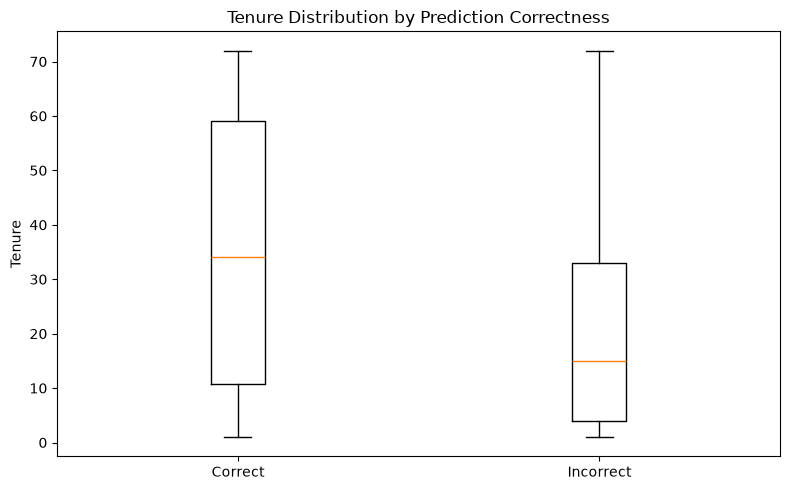

In [67]:
# Visualization

plt.figure(figsize=(8,5))

plt.boxplot(
    [
        correct_df["tenure"],
        incorrect_df["tenure"]
    ],
    tick_labels=["Correct", "Incorrect"]
)

plt.ylabel("Tenure")
plt.title("Tenure Distribution by Prediction Correctness")

plt.tight_layout()
plt.savefig("../figures/Sprint11/tenure_boxplot.png", dpi=300)

plt.show()

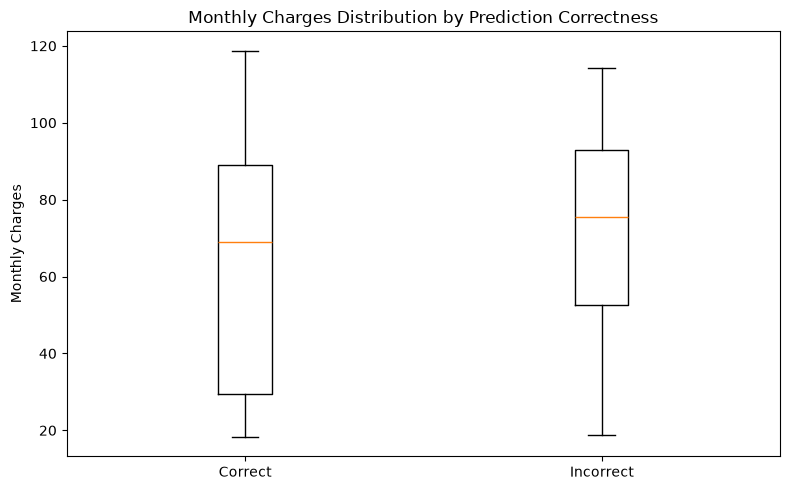

In [68]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        correct_df["MonthlyCharges"],
        incorrect_df["MonthlyCharges"]
    ],
    tick_labels=["Correct", "Incorrect"]
)

plt.ylabel("Monthly Charges")
plt.title("Monthly Charges Distribution by Prediction Correctness")

plt.tight_layout()
plt.savefig("../figures/Sprint11/monthlycharges_boxplot.png", dpi=300)

plt.show()

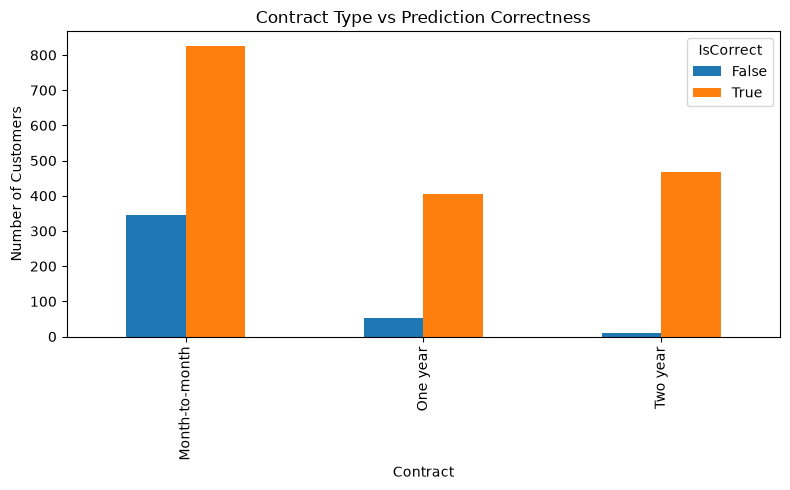

In [69]:
contract_counts = pd.crosstab(
    analysis_df["Contract"],
    analysis_df["IsCorrect"]
)

contract_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Contract Type vs Prediction Correctness")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../figures/Sprint11/contract_barplot.png", dpi=300)

plt.show()

## Engineering Analysis

Error Analysis provided valuable insights into the weaknesses of the final Logistic Regression model.

The analysis showed that incorrectly classified customers generally have significantly shorter tenure compared to correctly classified customers. This suggests that recently acquired customers exhibit less stable behavioral patterns, making churn prediction more difficult.

In addition, customers with higher monthly charges were more frequently misclassified, indicating that pricing alone is not sufficient for distinguishing churn behavior and may require interaction with other features.

Contract type also proved to be an important factor. Most prediction errors occurred among customers with month-to-month contracts, while customers with one-year and especially two-year contracts were classified much more reliably.

Overall, these findings indicate that future improvements should focus on feature engineering for new customers, interaction-based features, and additional behavioral information rather than relying solely on hyperparameter tuning.

## Key Findings

- Error Analysis identified customer groups where the model performs less reliably.
- Customers with shorter tenure generate a larger proportion of prediction errors.
- Higher MonthlyCharges are associated with increased classification difficulty.
- Month-to-month contracts produce substantially more errors than long-term contracts.
- Long-term contracts remain the easiest customer segment for the model to classify.
- The current model's limitations are likely related to feature representation rather than model complexity.
- Future improvements should prioritize Feature Engineering and additional customer behavior features.

## Sprint Retrospective

This sprint shifted the focus from model optimization to understanding model behavior.

Instead of concentrating on improving evaluation metrics, the analysis investigated where and why prediction errors occur. This process demonstrated that model evaluation does not end after obtaining Accuracy or Recall scores. Understanding failure cases provides practical insights for future improvements.

The sprint also reinforced the importance of interpreting False Positives and False Negatives from both engineering and business perspectives, allowing better prioritization of future development efforts.

Overall, this sprint established a systematic workflow for error diagnosis that will guide future feature engineering and model refinement.